In [1]:
import scanpy as sc
import pandas as pd

import sys, os

import matplotlib.pyplot as plt
import palettable

In [2]:
import os, sys
os.chdir('../../data')
sys.path.append('../src')

In [3]:
import vis
from vis import plot_veres_panel

In [4]:
os.chdir('../analysis')

intermediate_directory = '/Users/stanleydale/user_generated/breault-lab/single-cell/analysis'

d4_as_clustered = sc.read_h5ad(f'{intermediate_directory}/clustered_egfDuod_D4_AS_DZ.h5ad')

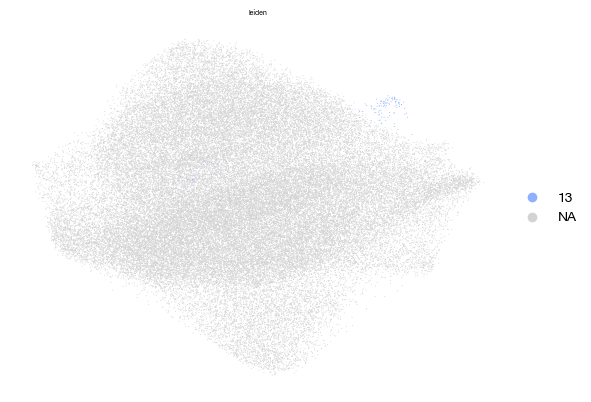

In [5]:
sc.pl.umap(
    d4_as_clustered,
    color="leiden",
    palette=sc.pl.palettes.default_102,  # or sc.pl.palettes.zeileis_28
    groups=["13"],
    frameon=False
)

In [6]:
### Cluster 13 are our EECs, or our 'NEUROG3 + PCs'

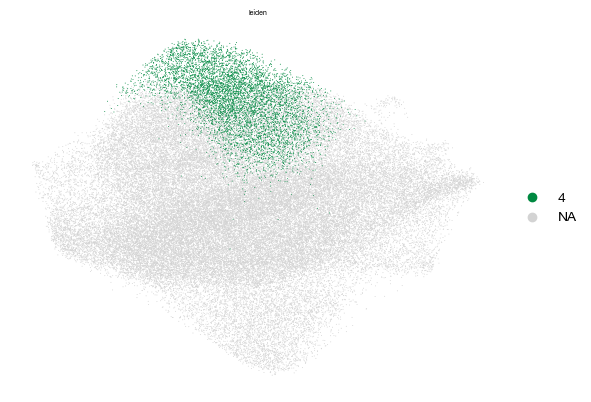

In [7]:
### Let's identify our proliferating PCs

sc.pl.umap(
    d4_as_clustered,
    color="leiden",
    palette=sc.pl.palettes.default_102,  # or sc.pl.palettes.zeileis_28
    groups=["4"],
    frameon=False
)

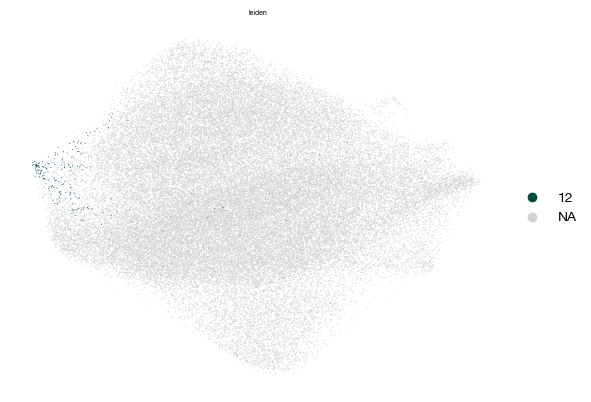

In [8]:
sc.pl.umap(
    d4_as_clustered,
    color="leiden",
    palette=sc.pl.palettes.default_102,  # or sc.pl.palettes.zeileis_28
    groups=["12"],
    frameon=False
)

In [9]:

import numpy as np
from scipy.sparse import issparse

def gene_expr_bool(adata, gene, threshold=0.0):
    """
    Return a boolean array (n_cells,) indicating which cells express `gene`
    above `threshold` in adata.X.
    If the gene is missing, returns all False.
    """
    if gene not in adata.var_names:
        print(f"Warning: {gene} not found in var_names; treating as not expressed.")
        return np.zeros(adata.n_obs, dtype=bool)
    
    sub = adata[:, gene]
    X = sub.X
    if issparse(X):
        X = X.toarray()
    X = np.ravel(X)
    return X > threshold

In [10]:
# Make sure leiden is string
d4_as_clustered.obs["leiden"] = d4_as_clustered.obs["leiden"].astype(str)

# Base label for everything
d4_as_clustered.obs["manual_label"] = "PCs"

# Enterocytes: cluster 7
fabp1_pos_as = gene_expr_bool(d4_as_clustered, "FABP1")
mask_ent_as = (d4_as_clustered.obs["leiden"] == "7") & fabp1_pos_as
d4_as_clustered.obs.loc[mask_ent_as, "manual_label"] = "Enterocytes"


# NEUROG3+ progenitor cells
neurog3_pos_as = gene_expr_bool(d4_as_clustered, "NEUROG3")
mask_inflammed_lapa = d4_as_clustered.obs["leiden"] == "13"
d4_as_clustered.obs.loc[mask_inflammed_lapa, "manual_label"] = "NEUROG3+ progenitor cells"

# ISCs: LGR5+ cells anywhere
lgr5_pos_as = gene_expr_bool(d4_as_clustered, "LGR5")
d4_as_clustered.obs.loc[lgr5_pos_as, "manual_label"] = "ISCs"

# --- Proliferating PCs: MKI67+ in cluster 4 (overrides other labels) ---
mki67_pos_as = gene_expr_bool(d4_as_clustered, "MKI67")
mask_prolif_pc_as = (d4_as_clustered.obs["leiden"] == "4") & mki67_pos_as
d4_as_clustered.obs.loc[mask_prolif_pc_as, "manual_label"] = "Proliferating PCs"

# Sanity check
print(d4_as_clustered.obs["manual_label"].value_counts())

manual_label
PCs                          53519
ISCs                          8993
Proliferating PCs             1786
Enterocytes                    531
NEUROG3+ progenitor cells      127
Name: count, dtype: int64


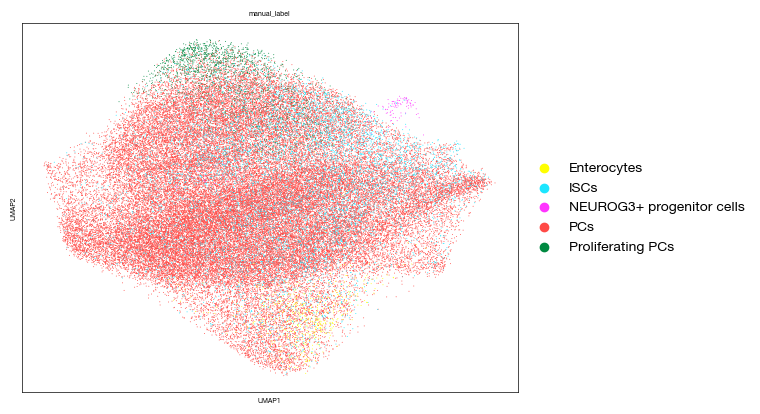

In [11]:
sc.pl.umap(d4_as_clustered, color = 'manual_label', palette=sc.pl.palettes.default_102,  # or sc.pl.palettes.zeileis_28
)

In [12]:
sc.write('manual_labelled/d4_as_manual_labels.h5ad', d4_as_clustered)